# Customer Churn Business EDA

## Business Problem
Customer churn is leading to significant recurring revenue loss.  
The primary objective of this analysis is to identify:

- Customer segments with the highest churn risk
- Revenue leakage across different segments
- Early warning indicators of churn
- Data-driven actions to improve customer retention

---

## Analytical Goals

This notebook focuses on:

- KPI-driven churn evaluation
- Revenue impact assessment
- Segment-level churn behaviour
- Actionable and business-oriented insights

In [45]:
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("../data/telco_churn_cleaned_v1.csv")

In [5]:
df.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
senior_citizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phone_service,No,Yes,Yes,No,Yes
multiple_lines,No phone service,No,No,No phone service,No
internet_service,DSL,DSL,DSL,DSL,Fiber optic
online_security,No,Yes,Yes,Yes,No
online_backup,Yes,No,Yes,No,No


## 📊 Churn Overview — Key Business KPIs

This section quantifies the overall churn problem in terms of:

- Customer volume
- Revenue impact
- Churn rate
- Average customer value

In [8]:
total_customers = df.shape[0]
print(total_customers)

7043


In [10]:
total_churned = df['churn_flag'].sum()
print(total_churned)

1869


In [11]:
churn_rate = df['churn_flag'].mean()*100
print(churn_rate)

26.536987079369588


In [12]:
avg_monthly_revenue = df['monthly_charges'].mean()
print(avg_monthly_revenue)

64.76169246059918


In [14]:
total_monthly_revenue = df['monthly_charges'].sum()
print(total_monthly_revenue)

456116.6


In [16]:
revenue_lost = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print(revenue_lost)

139130.85


In [37]:
percent_revenue_lost = revenue_lost/total_monthly_revenue*100
print(percent_revenue_lost)

30.503351555282137


### 🔍 KPI Insights

- The overall churn rate is **26.5%**, indicating that roughly 1 in 4 customers is leaving.
- Churned customers contribute to **30.5% of total monthly revenue loss**, which is disproportionately high.

### 💡 Business Interpretation
Churn is not coming from low-value customers —  
**higher-paying customers are more likely to leave.**

### 🚀 Business Risk
This creates a double impact:

- Customer loss
- High-value revenue loss

Retention strategies must prioritize **revenue-weighted segments**, not just customer count.

## 📉 Churn by Contract Type

Contract duration reflects customer commitment and is a key retention driver.

In [19]:
contract_churn = pd.crosstab(df['contract'],df['churn_flag'], normalize='index')*100
print(contract_churn)

churn_flag              0          1
contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


### 🔍 Key Insight

- Month-to-month contracts show the highest churn rate.
- Long-term contracts (one-year and two-year) significantly reduce churn.

### 💡 Business Meaning
Customers without long-term commitment are highly volatile.

### 💰 Revenue Impact
More than **85% of total churn-related revenue loss comes from month-to-month customers**, making this the **primary revenue risk segment**.

### ✅ Recommended Action
Introduce:

- Contract upgrade incentives
- Loyalty pricing for long-tenure customers

## ⏳ Churn by Customer Tenure

Customer lifecycle stage is a strong predictor of churn behavior.

In [21]:
tenure_group_churn = pd.crosstab(df['tenure_group'],df['churn_flag'], normalize='index')*100
print(tenure_group_churn)

churn_flag            0          1
tenure_group                      
0-12          52.561757  47.438243
12-24         71.289062  28.710938
24-48         79.611041  20.388959
48+           90.486824   9.513176


### 🔍 Key Insight

Customers in their first 12 months churn at a significantly higher rate  
compared to long-tenure customers.

### 💡 Business Meaning
The onboarding and early engagement experience is failing.

### 🚀 Retention Opportunity
The **first-year customer journey is the most critical retention window.**

### ✅ Recommended Action

- Early-life engagement programs
- First-year loyalty benefits
- Proactive support for new customers

## 💳 Churn by Payment Method

Payment behavior often reflects customer intent and stability.

In [22]:
payment_method_churn = pd.crosstab(df['payment_method'], df['churn_flag'], normalize='index')*100
print(payment_method_churn)

churn_flag                         0          1
payment_method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


### 🔍 Key Insight

Electronic check users show the highest churn rate.

### ⚠ Important Analytical Note
This may be influenced by contract type rather than payment behavior alone.

### 💡 Business Meaning
Payment method acts as a **behavioral signal**, not necessarily the root cause.

### ✅ Recommended Action

- Encourage auto-pay adoption
- Offer incentives for automatic payment methods

## 🌐 Churn by Internet Service Type

In [23]:
internet_service_churn = pd.crosstab(df['internet_service'], df['churn_flag'], normalize='index')*100
print(internet_service_churn)

churn_flag                0          1
internet_service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


In [38]:
df.groupby('internet_service')['monthly_charges'].mean()

internet_service
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: monthly_charges, dtype: float64

### 🔍 Key Insight

Fiber optic customers have higher churn despite generating higher revenue.

### 💡 Business Meaning

This is likely driven by **higher monthly charges**, not just service quality.

### ⚠ Risk

High-paying customers are more price-sensitive.

### ✅ Recommended Action

- Bundle value-added services
- Introduce premium customer retention plans

## 💵 Monthly Charges Distribution

<Axes: xlabel='monthly_charges', ylabel='Count'>

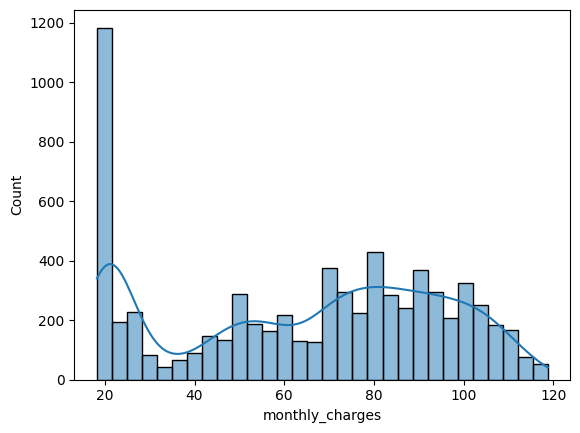

In [25]:
sns.histplot(df['monthly_charges'], bins=30, kde=True)

<Axes: xlabel='churn_flag', ylabel='monthly_charges'>

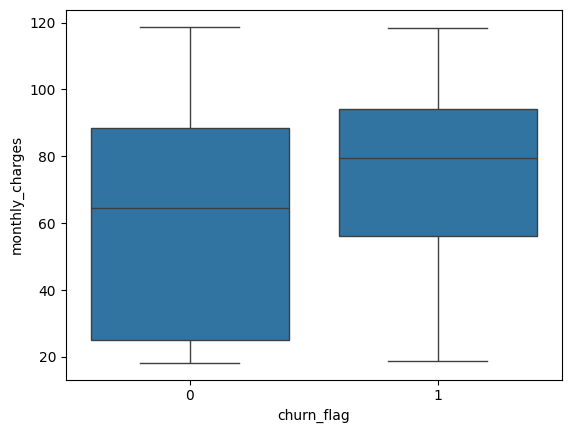

In [26]:
sns.boxplot(x='churn_flag', y='monthly_charges', data=df)

### 🔍 Key Insight

Customers who churn pay higher monthly charges on average.

### 💡 Business Meaning

Price sensitivity is a major churn driver.

### 🚨 Revenue Risk

Losing these customers results in **disproportionately high revenue loss**.

### ✅ Recommended Action

- Smart discounting for high-value customers
- Personalized pricing strategies

In [47]:
avg_charge_by_churn = df.groupby('churn_flag')['monthly_charges'].mean()
avg_charge_by_churn

churn_flag
0    61.265124
1    74.441332
Name: monthly_charges, dtype: float64

In [48]:
price_diff_pct = ((avg_charge_by_churn[1] - avg_charge_by_churn[0])/ avg_charge_by_churn[0])*100
price_diff_pct

np.float64(21.50686683234689)

### 💰 Revenue Risk — Price Sensitivity

Churned customers pay significantly higher monthly charges than retained customers.

- Average monthly charge (retained): lower
- Average monthly charge (churned): higher
- Percentage difference: **~21% higher**

### 💡 Business Meaning

High-value customers are more likely to churn.

This confirms that churn is a **revenue-quality problem**, not just a customer-count problem.

### 🚀 Strategic Implication

Retention efforts must prioritize **high ARPU customers**, as saving fewer customers here protects more revenue.

## 💰 Revenue Leakage by Contract Type

In [28]:
revenue_lost_by_contract = df[df['churn_flag']==1].groupby('contract')['monthly_charges'].sum()
print(revenue_lost_by_contract)

contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: monthly_charges, dtype: float64


### 🔍 Key Insight

Month-to-month customers contribute the overwhelming majority of revenue loss.

### 💡 Business Meaning

Improving retention in this segment will produce the **highest financial impact**.

## 🔥 High-Risk Customer Segment Identification

We now combine:

- Contract type
- Tenure group

to locate the **highest churn + highest revenue segment**.

In [32]:
high_risk = df[df['contract']=='Month-to-month']
print(high_risk['monthly_charges'].sum() / total_monthly_revenue*100)

56.40973163441103


In [36]:
risk_segment = pd.crosstab([df['contract'], df['tenure_group']], df['churn_flag'], normalize='index')*100
print(risk_segment)

churn_flag                            0          1
contract       tenure_group                       
Month-to-month 0-12           48.645938  51.354062
               12-24          62.279512  37.720488
               24-48          67.082294  32.917706
               48+            73.976608  26.023392
One year       0-12           89.516129  10.483871
               12-24          91.878173   8.121827
               24-48          89.382239  10.617761
               48+            87.066246  12.933754
Two year       0-12          100.000000   0.000000
               12-24         100.000000   0.000000
               24-48          97.810219   2.189781
               48+            96.674584   3.325416


### 🏆 Top Revenue Leakage Segment

Month-to-month customers in the early tenure stage form the highest-risk group.

### 💡 Business Meaning

This segment:

- Churns the most
- Generates substantial revenue
- Has low commitment

### 🎯 Strategic Focus

Retention campaigns should be **primarily targeted here** for maximum ROI.

## 🏆 Churn Reduction Priority Ranking

Not all churn segments have equal business impact.

We rank customer segments using:

**Priority Score = churn rate × revenue share**

This identifies where retention efforts will deliver the highest financial return.

In [54]:
segment_summary = df.groupby(['contract', 'tenure_group']).agg(
    churn_rate=('churn_flag', 'mean'),
    segment_revenue=('monthly_charges', 'sum'),
    revenue_loss=('monthly_charges', lambda x: x[df.loc[x.index, 'churn_flag'] == 1].sum())
).reset_index()

segment_summary['revenue_share'] = (segment_summary['segment_revenue'] / segment_summary['segment_revenue'].sum())

segment_summary['priority_score'] = (segment_summary['churn_rate'] * segment_summary['revenue_share'])

segment_summary = segment_summary.sort_values(by='priority_score', ascending=False).reset_index(drop=True)

segment_summary.style.format({'churn_rate': '{:.2%}', 'revenue_share': '{:.2%}', 'priority_score': '{:.4f}'})

,contract,tenure_group,churn_rate,segment_revenue,revenue_loss,revenue_share,priority_score
0,Month-to-month,0-12,51.35%,116086.500000,68301.450000,25.45%,0.1307
1,Month-to-month,24-48,32.92%,60904.050000,22557.000000,13.35%,0.0440
2,Month-to-month,12-24,37.72%,51081.150000,21980.300000,11.20%,0.0422
3,Month-to-month,48+,26.02%,29222.450000,8008.350000,6.41%,0.0167
4,One year,48+,12.93%,50443.300000,7842.950000,11.06%,0.0143
5,One year,24-48,10.62%,32093.300000,4521.350000,7.04%,0.0075
6,Two year,48+,3.33%,85897.950000,3781.150000,18.83%,0.0063
7,One year,12-24,8.12%,8841.100000,1101.350000,1.94%,0.0016
8,One year,0-12,10.48%,4438.900000,652.800000,0.97%,0.0010
9,Two year,24-48,2.19%,12095.950000,384.150000,2.65%,0.0006


### 🔥 Top Priority Segment

The highest-priority segment combines:

- High churn probability
- High revenue contribution

This is the segment where retention action will generate the **maximum ROI**.

### 🎯 How to Use This

Instead of targeting all churn equally:

Focus first on the **top-ranked segment**.

This ensures:

- Faster revenue protection
- Efficient retention spending
- Measurable business impact

# 📌 Key Business Insights

### Top Churn Drivers

- Month-to-month contracts
- First-year customers
- High monthly charges

### Highest Revenue Risk Segment

Month-to-month customers in early tenure.

### Early Warning Signals

- High monthly charge
- Electronic check payment
- Short tenure

# 🚀 Business Recommendations

1. Migrate customers to long-term contracts through incentives.
2. Strengthen first-year onboarding and engagement.
3. Protect high-value customers with personalized retention plans.
4. Promote automatic payment methods.

## 📌 Retention Strategy — Action Priority

### 1️⃣ Immediate Focus
Top-ranked segment from priority model.

### 2️⃣ Secondary Focus
High churn but moderate revenue segments.

### 3️⃣ Monitor Only
Low churn + low revenue segments.